In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
from datetime import datetime

import sys
sys.path.append('../..')
from utils_plot import plot_colors

In [2]:
lake='neuchatel'
base_dir = f"/storage/alplakes_test/{lake}_100m_2025"
modal_analysis_dir = os.path.join(base_dir, "modal_analysis")
output_dir = os.path.join(modal_analysis_dir, "figures")

In [3]:
os.makedirs(output_dir, exist_ok=True)

In [4]:
ds_results = xr.open_dataset(os.path.join(modal_analysis_dir, "KE_projected.nc"))

In [5]:
from glob import glob

files = [
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z0-9.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z10-19.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z20-29.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z30-39.nc"))),
    sorted(glob(os.path.join(modal_analysis_dir, "KE_month*_Z40-49.nc"))),
]

ds_results = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim=["Z", "time"]
)

In [6]:
ds_results.KE.to_netcdf(os.path.join(modal_analysis_dir, "KE_projected.nc"))

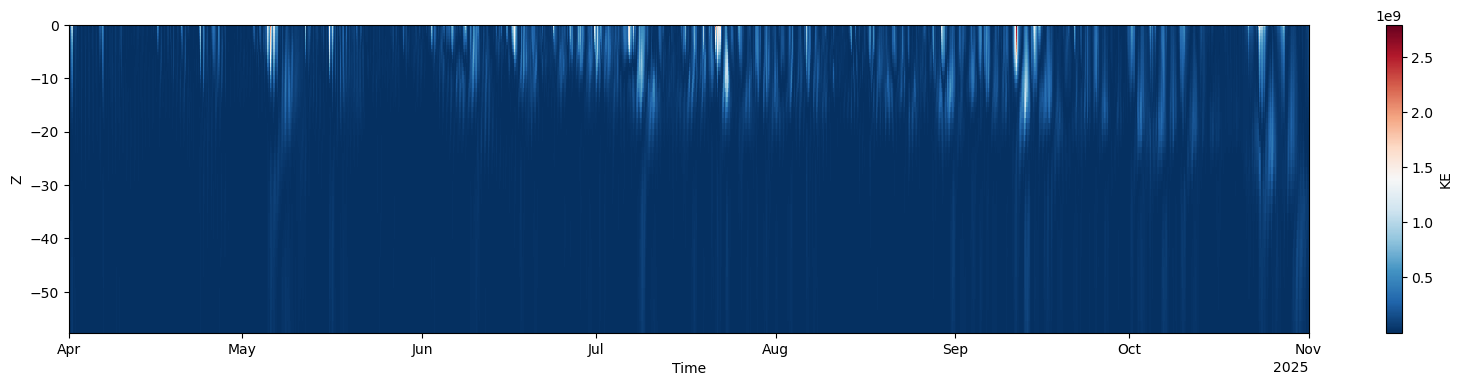

In [7]:
plt.figure(figsize=(20,4))
ds_results.KE.sum(dim=['mode']).plot(cmap='RdBu_r')

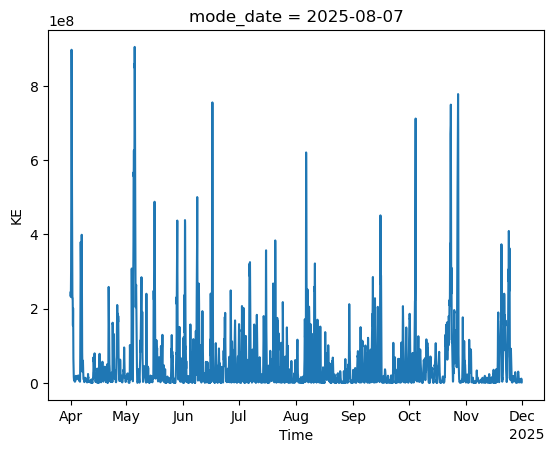

In [ ]:
ds_results.KE.isel(Z=range(0,1)).sum(dim=['mode','Z']).plot()

In [10]:
ke_filtered_by_depth = (ds_results.KE.isel(Z=range(50)).sum(dim=['mode', 'Z'])/1e6)

In [22]:
aligned_u = ds_results.isel(time=range(31*24)).U_real.sum(dim=['mode'])

In [23]:
aligned_u = ds_results.isel(time=range(31*24)).U_real.sum(dim=['mode']).rename({'XG':'XC'})
aligned_u['XC'] = ds_results['XC']

aligned_v = ds_results.isel(time=range(31*24)).V_real.sum(dim=['mode']).rename({'YG':'YC'})
aligned_v['YC'] = ds_results['YC']

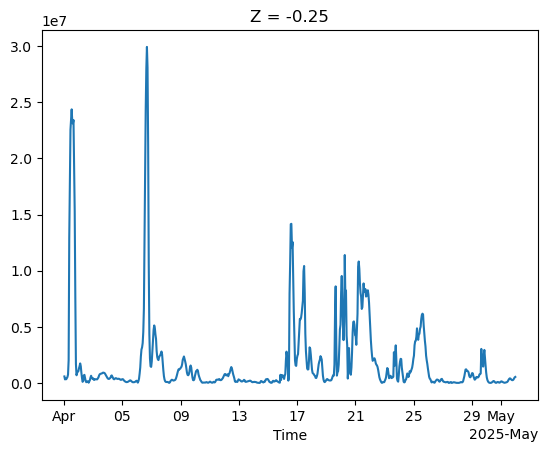

In [28]:
(0.5 * 1000 * (aligned_u.isel(Z=0)**2 + aligned_v.isel(Z=0)**2)*100*100*0.5).sum(dim=['XC','YC']).plot()

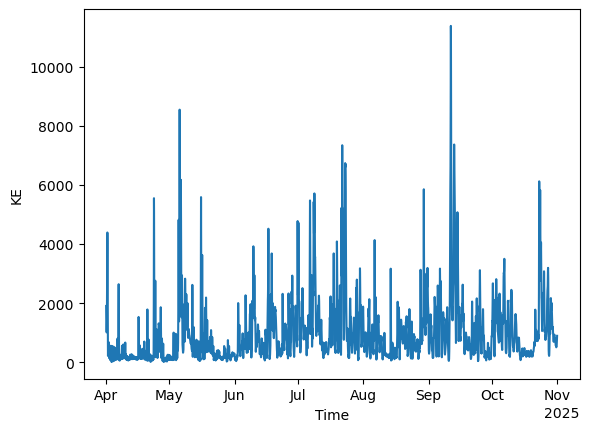

In [11]:
ke_filtered_by_depth.plot()

In [11]:
csv_name = f"ke_seiche_{ds_results.Z.isel(Z=0):.2f}-{ds_results.Z.isel(Z=49):.1f}m.csv"
ke_filtered_by_depth.to_dataframe(name='kinetic_energy_[MJ]').to_csv(os.path.join(modal_analysis_dir, csv_name))

# Comparison with total KE

In [5]:
ke_tot = xr.open_dataarray(os.path.join(base_dir, 'energy_budget', "kinetic_energy.nc"))

In [7]:
import pandas as pd

In [19]:
test = ke_tot.isel(Z=range(0,10)).sel(time=slice(pd.to_datetime('2025-07-01'), pd.to_datetime('2025-07-10'))).sum(dim=['XC','YC','Z'])

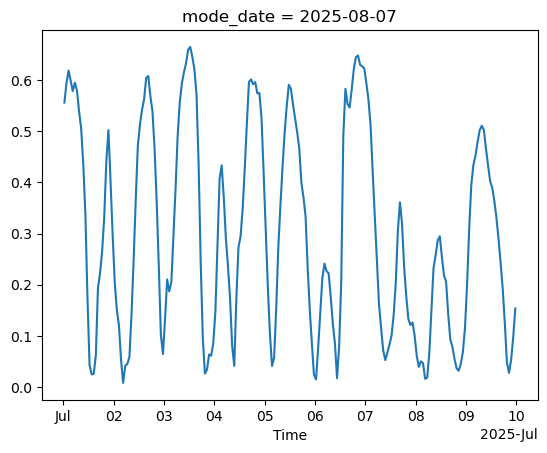

In [20]:
((ds_results.KE.isel(Z=range(0,10)).sel(time=test.time).sum(dim=['mode','Z'])/1e6)/test).plot()

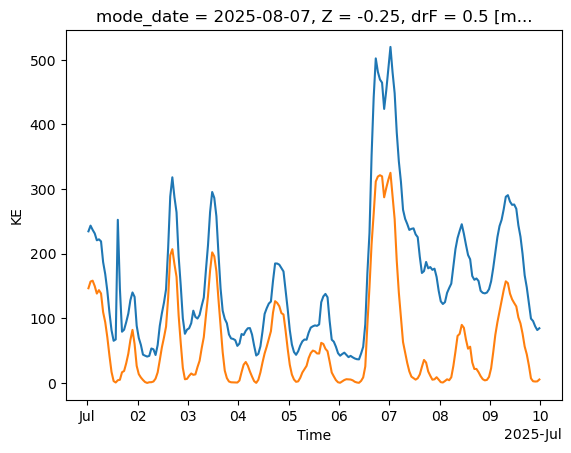

In [ ]:
test.plot()
(ds_results.KE.isel(Z=0).sel(time=test.time).sum(dim=['mode'])/1e6).plot()


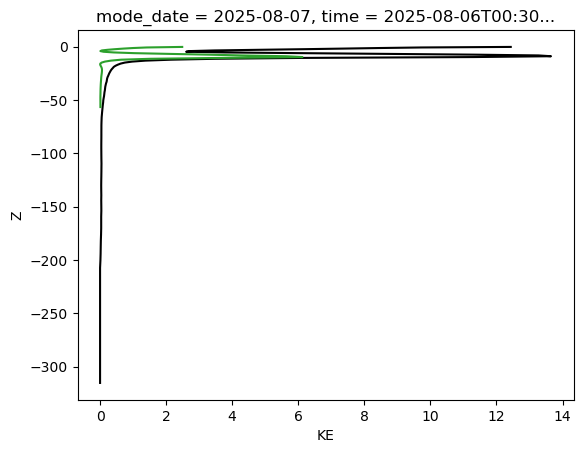

In [8]:
date = datetime(2025,8,6)
ke_tot.sel(time=date, method='nearest').sum(dim=['YC', 'XC']).plot(y='Z', c=plot_colors.ke_color)
(ds_results.KE.isel(mode_date=0).sel(time=date, method='nearest').sum(dim=['mode'])/1e6).plot(y='Z', c=plot_colors.iw_color)

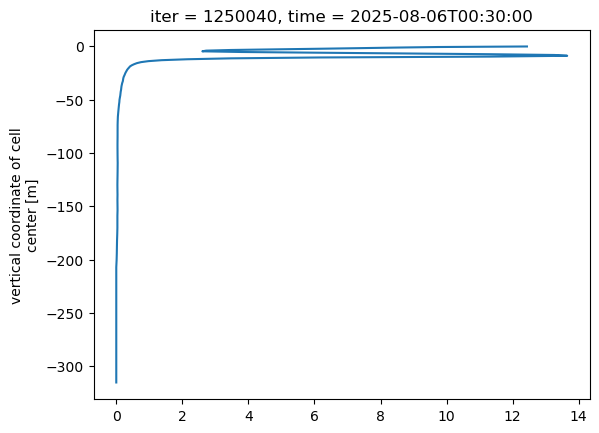

In [9]:
ke_tot.sel(time=datetime(2025,8,6), method='nearest').sum(dim=['YC', 'XC']).plot(y='Z')

# Comparison with filtered KE

In [11]:
import pandas as pd

ke_filtered = pd.read_csv(os.path.join(base_dir, 'seiche_analysis', "ke_seiche_surf_august.csv"))

In [26]:
ke_filtered = pd.read_csv(os.path.join(base_dir, 'modal_analysis', "ke_seiche_-0.25--39.2m.csv"))

,time,iter,kinetic_energy_[MJ]
2976,2025-08-03 00:30:00,1232760,73.156758
2977,2025-08-03 01:30:00,1233000,81.755361
2978,2025-08-03 02:30:00,1233240,72.967882
2979,2025-08-03 03:30:00,1233480,49.682923
2980,2025-08-03 04:30:00,1233720,28.434355
...,...,...,...
3307,2025-08-16 19:30:00,1312200,114.522772
3308,2025-08-16 20:30:00,1312440,224.716758
3309,2025-08-16 21:30:00,1312680,257.861878
3310,2025-08-16 22:30:00,1312920,229.468011


In [23]:
KE_MJ = ds_results.KE / 1e6

/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:518: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


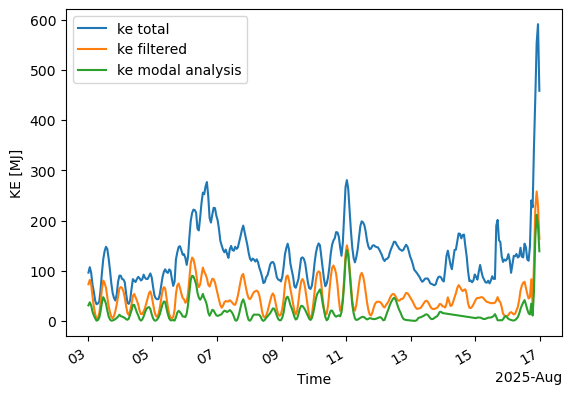

In [36]:
start_date = datetime(2025, 8, 3)
end_date = datetime(2025, 8, 17)


ke_tot_plot = ke_tot.isel(Z=range(0,16)).sel(time=slice(start_date, end_date)).sum(dim=['XC', 'YC', 'Z'])
ke_tot_plot.plot(label='ke total')

ke_filtered_date = ke_filtered[(pd.to_datetime(ke_filtered['time']) > start_date) & (pd.to_datetime(ke_filtered['time']) < end_date)]
ke_filtered_date.index = ke_tot.sel(time=slice(start_date, end_date)).time
ke_filtered_date['kinetic_energy_[MJ]'].plot(label='ke filtered')

ke_modal_plot = KE_MJ.sel(time=slice(start_date, end_date)).sum(dim=['mode', 'layer'])
ke_modal_plot.plot(label='ke modal analysis')

plt.ylabel('KE [MJ]')
plt.title('')
plt.legend()

In [39]:
print(f'KE filtered sum: {ke_filtered_date["kinetic_energy_[MJ]"].sum()}')
print(f'KE modal sum: {ke_modal_plot.sum().values}')
print(f'KE total sum: {ke_tot_plot.sum().values}')
print('')
print(f'KE filtered = {round(100*ke_filtered_date["kinetic_energy_[MJ]"].sum()/ke_tot_plot.sum().values,1)}%')
print(f'KE modal = {round(100*ke_modal_plot.sum().values/ke_tot_plot.sum().values,1)}%')

KE filtered sum: 16370.661894318942
KE modal sum: 6286.47439139533
KE total sum: 43203.58421920523

KE filtered = 37.9%
KE modal = 14.6%


Text(0, 0.5, 'KE [MJ]')

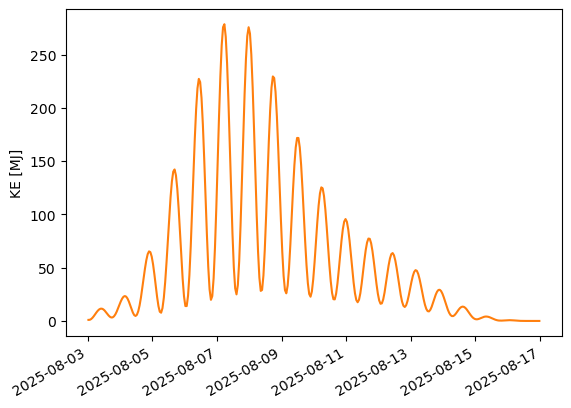

In [52]:
ke_filtered['ke_mj_total'].plot(label='ke filtered', c='tab:orange')
plt.ylabel('KE [MJ]')

# Ratio

In [11]:
ke_iw_filtered = (ds_results.KE.isel(mode_date=0, Z=range(40)).sum(dim=['mode', 'Z'])/1e6)
ke_tot_filtered = (ke_tot.isel(Z=range(40)).sum(dim=['XC', 'YC', 'Z'])/1e6)

KeyboardInterrupt: 